# Train and Tune LSTM Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.lstm import LSTMModel
from src.models.factory import Experiment
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.runners import run_experiments
from src.utils import results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.n_trials_nn
SPLITS = cfg.runtime.n_splits
TRAIN_RATIO = cfg.runtime.train_ratio
VAL_RATIO = cfg.runtime.val_ratio
GAP = cfg.runtime.gap
SUBSAMPLE_TRAIN = cfg.runtime.subsample_train
N_JOBS = cfg.runtime.n_jobs
rng = set_seed(SEED)

2025-09-13 16:26:51,226 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "lstm"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed, n_jobs: LSTMModel(horizon=horizon, random_state=seed, n_jobs=n_jobs),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(
    df=df_full,
    out_dir=Path(cfg.data.processed_dir),
    experiments=experiments,
    forecast_horizon=HORIZON,
    random_state=SEED,
    n_trials=TRIALS,
    n_splits=SPLITS,
    gap=GAP,
    subsample_train=SUBSAMPLE_TRAIN,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    n_jobs=N_JOBS
)

2025-09-13 16:26:51,267 - INFO - src.utils - Global random seed set to 42
2025-09-13 16:26:51,285 - INFO - ModelTrainer - Initialized trainer for lstm
2025-09-13 16:28:33,395 - INFO - ModelTrainer - Initialized trainer for lstm
2025-09-13 16:28:35,274 - INFO - ModelTrainer - Evaluating model...


In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, horizon=HORIZON)

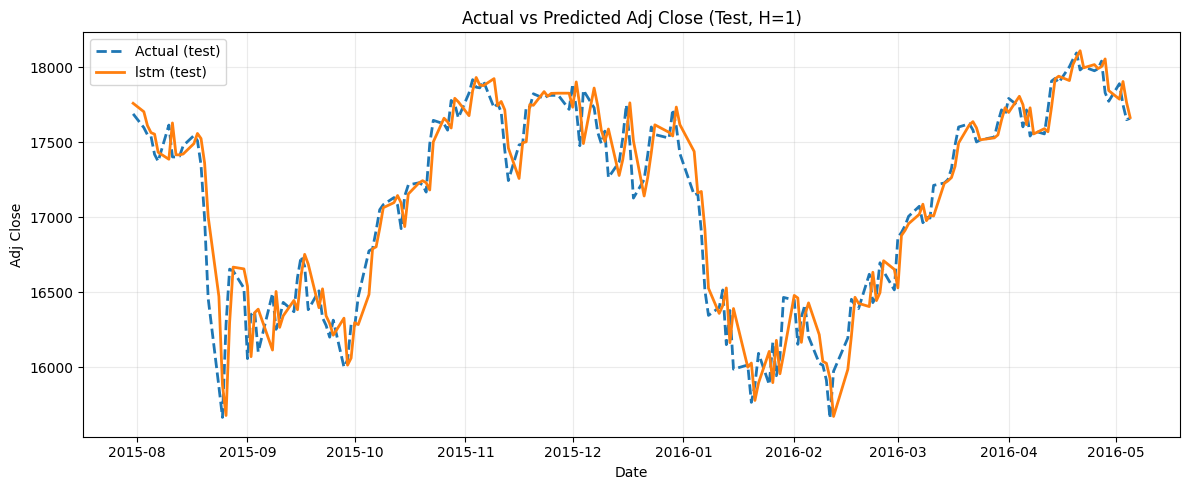

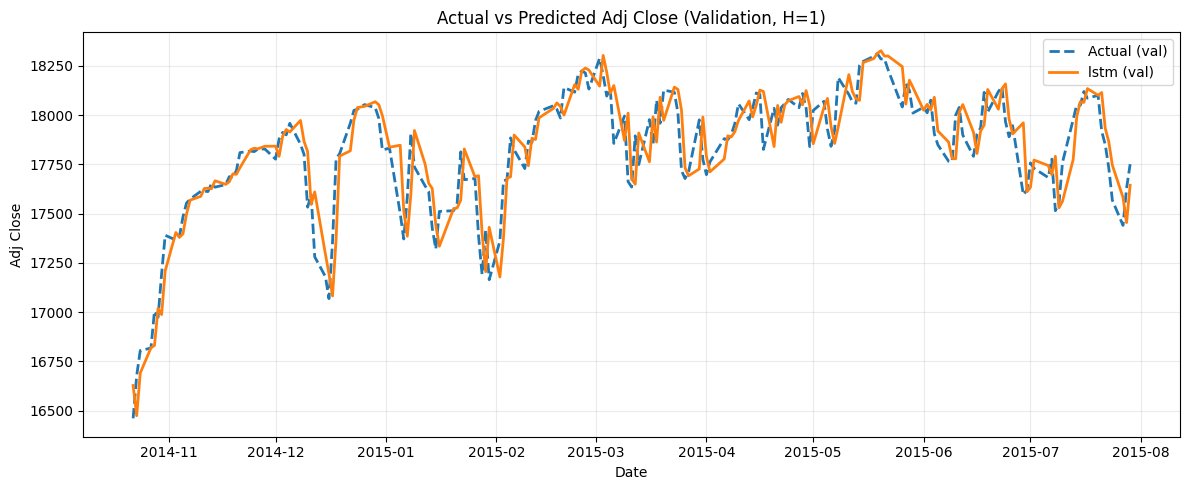

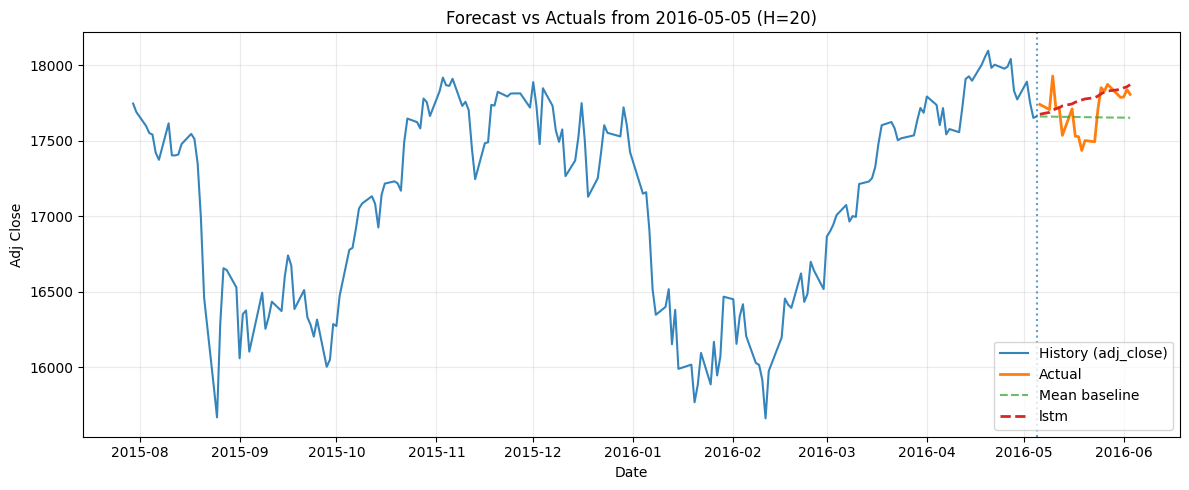

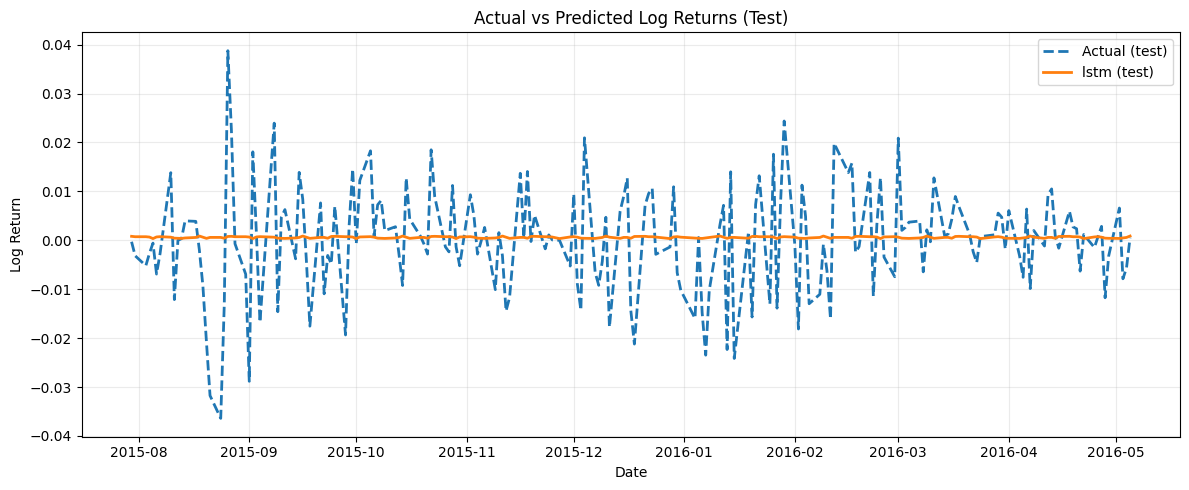

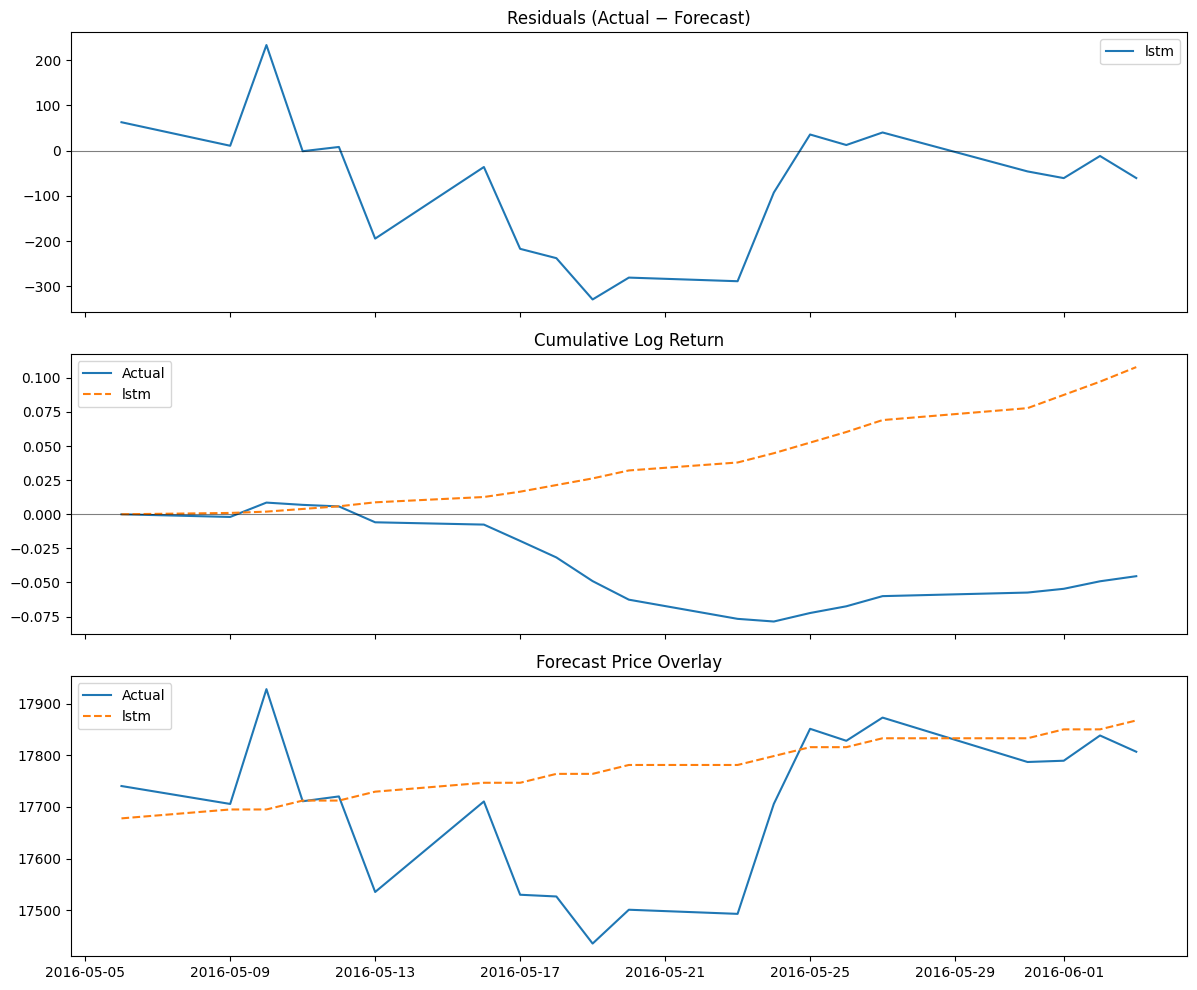

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_test.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_returns.png", "test")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,units,dense_units,dropout,lr,epochs,batch_size,bidirectional,weight_decay,random_state
0,lstm,48,48,0.29874,0.002954,60,32,False,0.000005,42


In [9]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,lstm,0.008156,0.000118,0.010843,-0.001902,0.529016


In [10]:
metrics_summary = results_to_df(results, ["metrics", "test", "per_horizon"])
metrics_summary = metrics_summary[metrics_summary["model"] == MODEL_NAME]
metrics_summary

,model,per_horizon,mae,mse,rmse,r2,directional_accuracy
0,lstm,1,0.008175,0.000120,0.010942,-5.495411e-03,0.518135
1,lstm,2,0.008166,0.000120,0.010934,-4.384063e-03,0.518135
2,lstm,3,0.008196,0.000120,0.010959,-3.335661e-03,0.523316
3,lstm,4,0.008244,0.000121,0.010991,-3.105216e-03,0.523316
4,lstm,5,0.008242,0.000121,0.010978,-7.188990e-04,0.528497
5,lstm,6,0.008257,0.000121,0.011008,-3.472566e-03,0.528497
6,lstm,7,0.008288,0.000122,0.011029,-3.389746e-03,0.533679
7,lstm,8,0.008276,0.000121,0.011010,-3.599807e-03,0.528497
8,lstm,9,0.008216,0.000120,0.010963,-1.307271e-03,0.528497
9,lstm,10,0.008243,0.000120,0.010969,-1.289347e-03,0.528497


In [11]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()